Analyse and plot model-human comparisons both for DE and ES, also for POS and Dependency Distance analysis.



# Overlap Comparison

## All Annotators

### Data Requirement

You will need the following Excel files (generated by previous scripts):

*   Summary_model-human_overlap_analysis_min_attribution_DE.xlsx
*   Summary_model-human_overlap_analysis_min_attribution_ES.xlsx
*   Summary_model-human_overlap_analysis_top_word_DE.xlsx
*   Summary_model-human_overlap_analysis_top_word_ES.xlsx
*   Summary_model-human_overlap_analysis_relative_attribution_DE.xlsx
*   Summary_model-human_overlap_analysis_relative_attribution_ES.xlsx
*   Summary_model-human_overlap_analysis_top_percentage_DE.xlsx
*   Summary_model-human_overlap_analysis_top_percentage_ES.xlsx


In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

### MICRO Precision

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

overlap_min_attribution_DE = pd.read_excel('Summary_model-human_overlap_analysis_min_attribution_DE.xlsx')
overlap_min_attribution_ES = pd.read_excel('Summary_model-human_overlap_analysis_min_attribution_ES.xlsx')
overlap_top_word_DE = pd.read_excel('Summary_model-human_overlap_analysis_top_word_DE.xlsx')
overlap_top_word_ES = pd.read_excel('Summary_model-human_overlap_analysis_top_word_ES.xlsx')
overlap_relative_attribution_DE = pd.read_excel('Summary_model-human_overlap_analysis_relative_attribution_DE.xlsx')
overlap_relative_attribution_ES = pd.read_excel('Summary_model-human_overlap_analysis_relative_attribution_ES.xlsx')
overlap_top_percentage_DE = pd.read_excel('Summary_model-human_overlap_analysis_top_percentage_DE.xlsx')
overlap_top_percentage_ES = pd.read_excel('Summary_model-human_overlap_analysis_top_percentage_ES.xlsx')

In [ ]:
# Define x- (threshold) and y-values (precision)
# Top Percentage
top_percentage_DE_precision = overlap_top_percentage_DE["Micro Precision"].values.tolist()
top_percentage_DE_threshold = overlap_top_percentage_DE["Threshold_%"].values.tolist()
top_percentage_ES_precision = overlap_top_percentage_ES["Micro Precision"].values.tolist()
top_percentage_ES_threshold = overlap_top_percentage_ES["Threshold_%"].values.tolist()
# Find average of lists
top_percentage_precision_avg = (np.array(top_percentage_DE_precision) + np.array(top_percentage_ES_precision))/2.0
top_percentage_precision_avg = top_percentage_precision_avg.tolist()
#print(top_percentage_precision_avg)

# Top word
overlap_top_word_DE_precision = overlap_top_word_DE["Micro Precision"].values.tolist()
overlap_top_word_DE_threshold = overlap_top_word_DE["Threshold_%"].values.tolist()
overlap_top_word_ES_precision = overlap_top_word_ES["Micro Precision"].values.tolist()
overlap_top_word_ES_threshold = overlap_top_word_ES["Threshold_%"].values.tolist()
# Find average of lists
top_word_precision_avg = (np.array(overlap_top_word_DE_precision) + np.array(overlap_top_word_ES_precision))/2.0
top_word_precision_avg = top_word_precision_avg.tolist()
#print(top_word_precision_avg)

# Minimum attribution score
min_attribution_DE_precision = overlap_min_attribution_DE["Micro Precision"].values.tolist()
min_attribution_DE_threshold = overlap_min_attribution_DE["Threshold_%"].values.tolist()
min_attribution_ES_precision = overlap_min_attribution_ES["Micro Precision"].values.tolist()
min_attribution_ES_threshold = overlap_min_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
min_attribution_precision_avg = (np.array(min_attribution_DE_precision) + np.array(min_attribution_ES_precision))/2.0
min_attribution_precision_avg = min_attribution_precision_avg.tolist()
#print(min_attribution_precision_avg)

# Relative attribution score
relative_attribution_DE_precision = overlap_relative_attribution_DE["Micro Precision"].values.tolist()
relative_attribution_DE_threshold = overlap_relative_attribution_DE["Threshold_%"].values.tolist()
relative_attribution_ES_precision = overlap_relative_attribution_ES["Micro Precision"].values.tolist()
relative_attribution_ES_threshold = overlap_relative_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
relative_attribution_precision_avg = (np.array(relative_attribution_DE_precision) + np.array(relative_attribution_ES_precision))/2.0
relative_attribution_precision_avg = relative_attribution_precision_avg.tolist()
#print(relative_attribution_precision_avg)

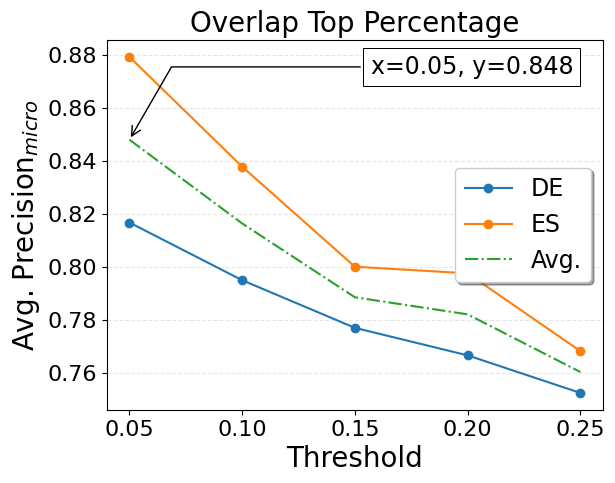

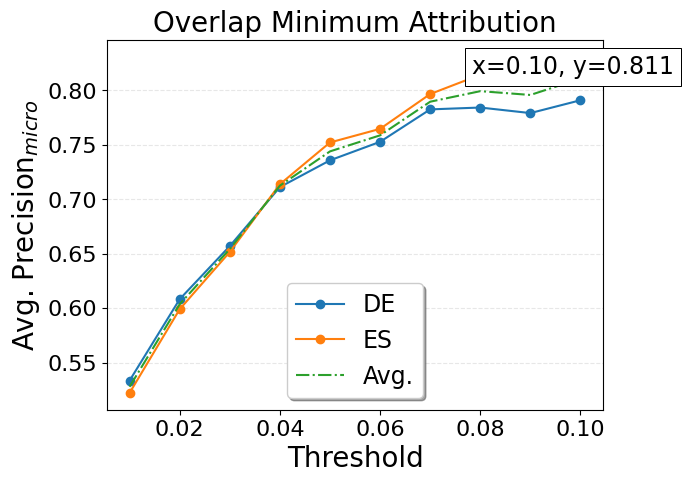

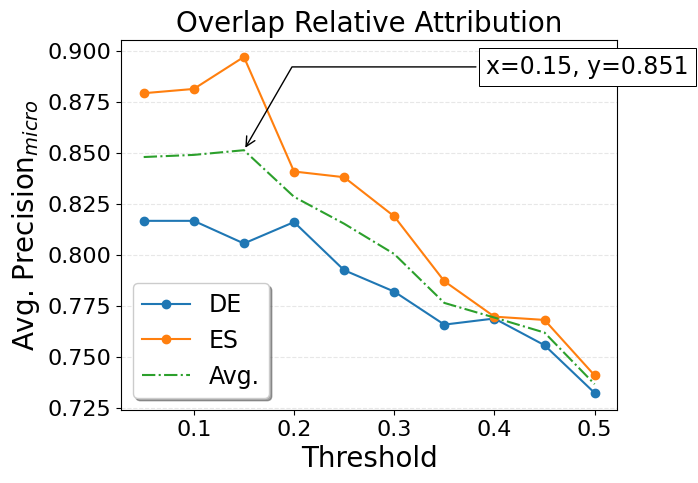

In [ ]:
## Top Percentage
fig, ax = plt.subplots()
ax.plot(top_percentage_DE_threshold, top_percentage_DE_precision, marker='o')
ax.plot(top_percentage_DE_threshold, top_percentage_ES_precision, marker='o')
ax.plot(top_percentage_DE_threshold, top_percentage_precision_avg, '-.')
plt.title('Overlap Top Percentage', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{micro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='center right', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(top_percentage_DE_threshold, top_percentage_precision_avg)

plt.savefig("micro_machine-human-overlap_top_percentage_DE-ES.jpg")
plt.show()
print("")


## Minimum Attribution Score
fig, ax = plt.subplots()
ax.plot(min_attribution_DE_threshold, min_attribution_DE_precision, marker='o')
ax.plot(min_attribution_ES_threshold, min_attribution_ES_precision, marker='o')
ax.plot(min_attribution_DE_threshold, min_attribution_precision_avg, '-.')
plt.title('Overlap Minimum Attribution', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{micro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower center', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="center", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min_attribution_DE_threshold, min_attribution_precision_avg)

plt.savefig("micro_machine-human-overlap_min_attribution_DE-ES.jpg")
plt.show()
print("")


## Relative Attribution Score
fig, ax = plt.subplots()
ax.plot(relative_attribution_DE_threshold, relative_attribution_DE_precision, marker='o')
ax.plot(relative_attribution_ES_threshold, relative_attribution_ES_precision, marker='o')
ax.plot(relative_attribution_DE_threshold, relative_attribution_precision_avg, '-.')
plt.title('Overlap Relative Attribution', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{micro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="center", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(relative_attribution_DE_threshold, relative_attribution_precision_avg)

plt.savefig("micro_machine-human-overlap_relative_attribution_DE-ES.jpg")
plt.show()
print("")

### MACRO Precision

#### Acces files and define variables

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

overlap_min_attribution_DE = pd.read_excel('Summary_model-human_overlap_analysis_min_attribution_DE.xlsx')
overlap_min_attribution_ES = pd.read_excel('Summary_model-human_overlap_analysis_min_attribution_ES.xlsx')
overlap_top_word_DE = pd.read_excel('Summary_model-human_overlap_analysis_top_word_DE.xlsx')
overlap_top_word_ES = pd.read_excel('Summary_model-human_overlap_analysis_top_word_ES.xlsx')
overlap_relative_attribution_DE = pd.read_excel('Summary_model-human_overlap_analysis_relative_attribution_DE.xlsx')
overlap_relative_attribution_ES = pd.read_excel('Summary_model-human_overlap_analysis_relative_attribution_ES.xlsx')
overlap_top_percentage_DE = pd.read_excel('Summary_model-human_overlap_analysis_top_percentage_DE.xlsx')
overlap_top_percentage_ES = pd.read_excel('Summary_model-human_overlap_analysis_top_percentage_ES.xlsx')

In [ ]:
# Define x- (threshold) and y-values (precision)
# Top Percentage
top_percentage_DE_precision = overlap_top_percentage_DE["Macro Precision"].values.tolist()
top_percentage_DE_threshold = overlap_top_percentage_DE["Threshold_%"].values.tolist()
top_percentage_ES_precision = overlap_top_percentage_ES["Macro Precision"].values.tolist()
top_percentage_ES_threshold = overlap_top_percentage_ES["Threshold_%"].values.tolist()
# Find average of lists
top_percentage_precision_avg = (np.array(top_percentage_DE_precision) + np.array(top_percentage_ES_precision))/2.0
top_percentage_precision_avg = top_percentage_precision_avg.tolist()
#print(top_percentage_precision_avg)

# Top word
overlap_top_word_DE_precision = overlap_top_word_DE["Macro Precision"].values.tolist()
overlap_top_word_DE_threshold = overlap_top_word_DE["Threshold_%"].values.tolist()
overlap_top_word_ES_precision = overlap_top_word_ES["Macro Precision"].values.tolist()
overlap_top_word_ES_threshold = overlap_top_word_ES["Threshold_%"].values.tolist()
# Find average of lists
top_word_precision_avg = (np.array(overlap_top_word_DE_precision) + np.array(overlap_top_word_ES_precision))/2.0
top_word_precision_avg = top_word_precision_avg.tolist()
#print(top_word_precision_avg)

# Minimum attribution score
min_attribution_DE_precision = overlap_min_attribution_DE["Macro Precision"].values.tolist()
min_attribution_DE_threshold = overlap_min_attribution_DE["Threshold_%"].values.tolist()
min_attribution_ES_precision = overlap_min_attribution_ES["Macro Precision"].values.tolist()
min_attribution_ES_threshold = overlap_min_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
min_attribution_precision_avg = (np.array(min_attribution_DE_precision) + np.array(min_attribution_ES_precision))/2.0
min_attribution_precision_avg = min_attribution_precision_avg.tolist()
#print(min_attribution_precision_avg)

# Relative attribution score
relative_attribution_DE_precision = overlap_relative_attribution_DE["Macro Precision"].values.tolist()
relative_attribution_DE_threshold = overlap_relative_attribution_DE["Threshold_%"].values.tolist()
relative_attribution_ES_precision = overlap_relative_attribution_ES["Macro Precision"].values.tolist()
relative_attribution_ES_threshold = overlap_relative_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
relative_attribution_precision_avg = (np.array(relative_attribution_DE_precision) + np.array(relative_attribution_ES_precision))/2.0
relative_attribution_precision_avg = relative_attribution_precision_avg.tolist()
#print(relative_attribution_precision_avg)

#### Define and run function to plot

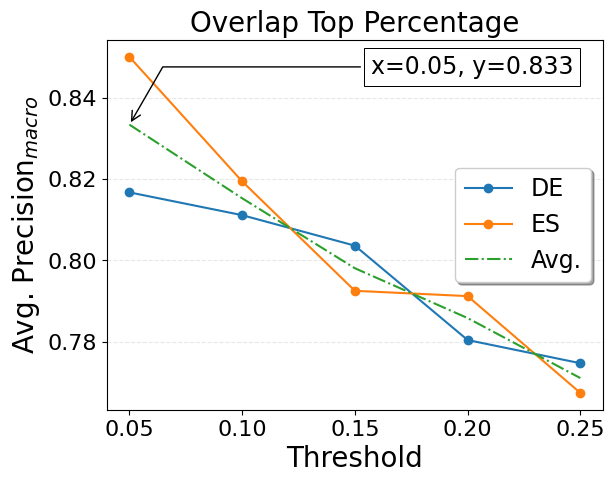

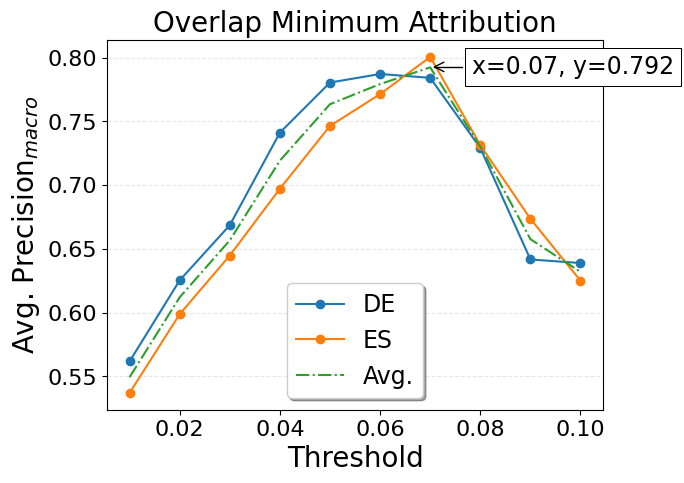

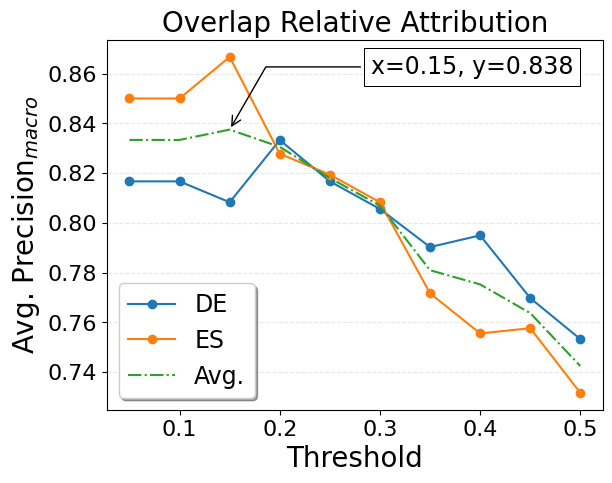

In [ ]:
## Top Percentage
fig, ax = plt.subplots()
ax.plot(top_percentage_DE_threshold, top_percentage_DE_precision, marker='o')
ax.plot(top_percentage_DE_threshold, top_percentage_ES_precision, marker='o')
ax.plot(top_percentage_DE_threshold, top_percentage_precision_avg, '-.')
plt.title('Overlap Top Percentage', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{macro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='center right', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(top_percentage_DE_threshold, top_percentage_precision_avg)

plt.savefig("macro_machine-human-overlap_top_percentage_DE-ES.jpg")
plt.show()
print("")


## Minimum Attribution Score
fig, ax = plt.subplots()
ax.plot(min_attribution_DE_threshold, min_attribution_DE_precision, marker='o')
ax.plot(min_attribution_ES_threshold, min_attribution_ES_precision, marker='o')
ax.plot(min_attribution_DE_threshold, min_attribution_precision_avg, '-.')
plt.title('Overlap Minimum Attribution', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{macro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower center', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="center", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min_attribution_DE_threshold, min_attribution_precision_avg)

plt.savefig("macro_machine-human-overlap_min_attribution_DE-ES.jpg")
plt.show()
print("")


## Relative Attribution Score
fig, ax = plt.subplots()
ax.plot(relative_attribution_DE_threshold, relative_attribution_DE_precision, marker='o')
ax.plot(relative_attribution_ES_threshold, relative_attribution_ES_precision, marker='o')
ax.plot(relative_attribution_DE_threshold, relative_attribution_precision_avg, '-.')
plt.title('Overlap Relative Attribution', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{macro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(relative_attribution_DE_threshold, relative_attribution_precision_avg)

plt.savefig("macro_machine-human-overlap_relative_attribution_DE-ES.jpg")
plt.show()
print("")

## Min2 Agree

### Data Requirement

You will need the following Excel files (generated by previous scripts):

*   Summary_model-human-min2_overlap_analysis_min_attribution_DE.xlsx
*   Summary_model-human-min2_overlap_analysis_min_attribution_ES.xlsx
*   Summary_model-human-min2_overlap_analysis_top_word_DE.xlsx
*   Summary_model-human-min2_overlap_analysis_top_word_ES.xlsx
*   Summary_model-human-min2_overlap_analysis_relative_attribution_DE.xlsx
*   Summary_model-human-min2_overlap_analysis_relative_attribution_ES.xlsx
*   Summary_model-human-min2_overlap_analysis_top_percentage_DE.xlsx
*   Summary_model-human-min2_overlap_analysis_top_percentage_ES.xlsx


### MACRO Precision

#### Acces files and define variables

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

overlap_min2_min_attribution_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_min_attribution_DE.xlsx')
overlap_min2_min_attribution_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_min_attribution_ES.xlsx')
overlap_min2_top_word_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_word_DE.xlsx')
overlap_min2_top_word_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_word_ES.xlsx')
overlap_min2_relative_attribution_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_relative_attribution_DE.xlsx')
overlap_min2_relative_attribution_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_relative_attribution_ES.xlsx')
overlap_min2_top_percentage_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_percentage_DE.xlsx')
overlap_min2_top_percentage_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_percentage_ES.xlsx')

In [ ]:
# Define x- (threshold) and y-values (precision)
# Top Percentage
min2_top_percentage_DE_precision = overlap_min2_top_percentage_DE["Macro Precision"].values.tolist()
min2_top_percentage_DE_threshold = overlap_min2_top_percentage_DE["Threshold_%"].values.tolist()
min2_top_percentage_ES_precision = overlap_min2_top_percentage_ES["Macro Precision"].values.tolist()
min2_top_percentage_ES_threshold = overlap_min2_top_percentage_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_top_percentage_precision_avg = (np.array(min2_top_percentage_DE_precision) + np.array(min2_top_percentage_ES_precision))/2.0
min2_top_percentage_precision_avg = min2_top_percentage_precision_avg.tolist()
#print(min2_top_percentage_precision_avg)

# Top word
min2_overlap_top_word_DE_precision = overlap_min2_top_word_DE["Macro Precision"].values.tolist()
min2_overlap_top_word_DE_threshold = overlap_min2_top_word_DE["Threshold_%"].values.tolist()
min2_overlap_top_word_ES_precision = overlap_min2_top_word_ES["Macro Precision"].values.tolist()
min2_overlap_top_word_ES_threshold = overlap_min2_top_word_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_top_word_precision_avg = (np.array(min2_overlap_top_word_DE_precision) + np.array(min2_overlap_top_word_ES_precision))/2.0
min2_top_word_precision_avg = min2_top_word_precision_avg.tolist()
#print(min2_top_word_precision_avg)

# Minimum attribution score
min2_min_attribution_DE_precision = overlap_min2_min_attribution_DE["Macro Precision"].values.tolist()
min2_min_attribution_DE_threshold = overlap_min2_min_attribution_DE["Threshold_%"].values.tolist()
min2_min_attribution_ES_precision = overlap_min2_min_attribution_ES["Macro Precision"].values.tolist()
min2_min_attribution_ES_threshold = overlap_min2_min_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_min_attribution_precision_avg = (np.array(min2_min_attribution_DE_precision) + np.array(min2_min_attribution_ES_precision))/2.0
min2_min_attribution_precision_avg = min2_min_attribution_precision_avg.tolist()
#print(min2_min_attribution_precision_avg)

# Relative attribution score
min2_relative_attribution_DE_precision = overlap_min2_relative_attribution_DE["Macro Precision"].values.tolist()
min2_relative_attribution_DE_threshold = overlap_min2_relative_attribution_DE["Threshold_%"].values.tolist()
min2_relative_attribution_ES_precision = overlap_min2_relative_attribution_ES["Macro Precision"].values.tolist()
min2_relative_attribution_ES_threshold = overlap_min2_relative_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_relative_attribution_precision_avg = (np.array(min2_relative_attribution_DE_precision) + np.array(min2_relative_attribution_ES_precision))/2.0
min2_relative_attribution_precision_avg = min2_relative_attribution_precision_avg.tolist()
#print(min2_relative_attribution_precision_avg)

#### Define function and run to plot

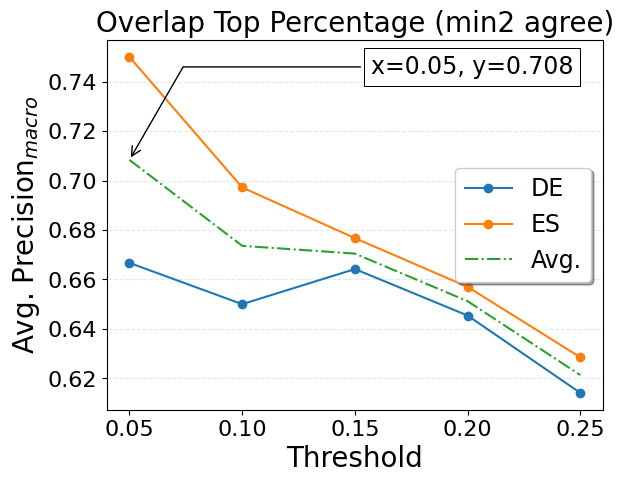

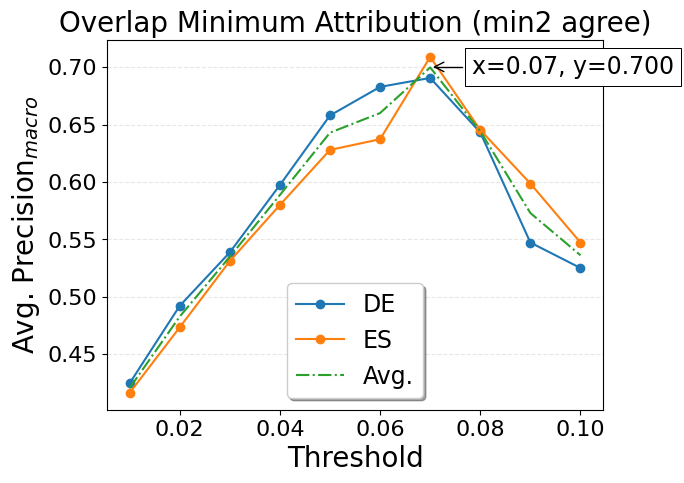

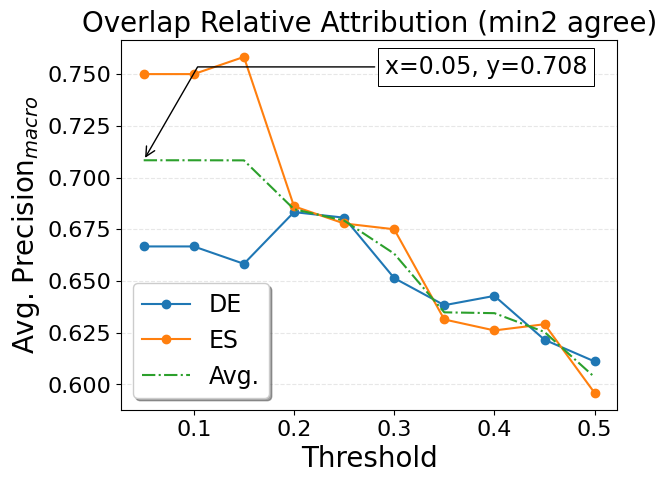

In [ ]:
## Top Percentage
fig, ax = plt.subplots()
ax.plot(min2_top_percentage_DE_threshold, min2_top_percentage_DE_precision, marker='o')
ax.plot(min2_top_percentage_DE_threshold, min2_top_percentage_ES_precision, marker='o')
ax.plot(min2_top_percentage_DE_threshold, min2_top_percentage_precision_avg, '-.')
plt.title('Overlap Top Percentage (min2 agree)', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{macro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='center right', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min2_top_percentage_DE_threshold, min2_top_percentage_precision_avg)

plt.savefig("macro_machine-human-min2-overlap_top_percentage_DE-ES.jpg")
plt.show()
print("")


## Minimum Attribution Score
fig, ax = plt.subplots()
ax.plot(min2_min_attribution_DE_threshold, min2_min_attribution_DE_precision, marker='o')
ax.plot(min2_min_attribution_ES_threshold, min2_min_attribution_ES_precision, marker='o')
ax.plot(min2_min_attribution_DE_threshold, min2_min_attribution_precision_avg, '-.')
plt.title('Overlap Minimum Attribution (min2 agree)', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{macro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower center', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="center", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min2_min_attribution_DE_threshold, min2_min_attribution_precision_avg)

plt.savefig("macro_machine-human-min2-overlap_min_attribution_DE-ES.jpg")
plt.show()
print("")


## Relative Attribution Score
fig, ax = plt.subplots()
ax.plot(min2_relative_attribution_DE_threshold, min2_relative_attribution_DE_precision, marker='o')
ax.plot(min2_relative_attribution_ES_threshold, min2_relative_attribution_ES_precision, marker='o')
ax.plot(min2_relative_attribution_DE_threshold, min2_relative_attribution_precision_avg, '-.')
plt.title('Overlap Relative Attribution (min2 agree)', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{macro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min2_relative_attribution_DE_threshold, min2_relative_attribution_precision_avg)

plt.savefig("macro_machine-human-min2-overlap_relative_attribution_DE-ES.jpg")
plt.show()
print("")

### MICRO Precision

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

overlap_min2_min_attribution_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_min_attribution_DE.xlsx')
overlap_min2_min_attribution_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_min_attribution_ES.xlsx')
overlap_min2_top_word_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_word_DE.xlsx')
overlap_min2_top_word_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_word_ES.xlsx')
overlap_min2_relative_attribution_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_relative_attribution_DE.xlsx')
overlap_min2_relative_attribution_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_relative_attribution_ES.xlsx')
overlap_min2_top_percentage_DE = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_percentage_DE.xlsx')
overlap_min2_top_percentage_ES = pd.read_excel('Summary_model-human-min2_overlap_analysis_top_percentage_ES.xlsx')

In [ ]:
# Define x- (threshold) and y-values (precision)
# Top Percentage
min2_top_percentage_DE_precision = overlap_min2_top_percentage_DE["Micro Precision"].values.tolist()
min2_top_percentage_DE_threshold = overlap_min2_top_percentage_DE["Threshold_%"].values.tolist()
min2_top_percentage_ES_precision = overlap_min2_top_percentage_ES["Micro Precision"].values.tolist()
min2_top_percentage_ES_threshold = overlap_min2_top_percentage_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_top_percentage_precision_avg = (np.array(min2_top_percentage_DE_precision) + np.array(min2_top_percentage_ES_precision))/2.0
min2_top_percentage_precision_avg = min2_top_percentage_precision_avg.tolist()
#print(min2_top_percentage_precision_avg)

# Top word
min2_overlap_top_word_DE_precision = overlap_min2_top_word_DE["Micro Precision"].values.tolist()
min2_overlap_top_word_DE_threshold = overlap_min2_top_word_DE["Threshold_%"].values.tolist()
min2_overlap_top_word_ES_precision = overlap_min2_top_word_ES["Micro Precision"].values.tolist()
min2_overlap_top_word_ES_threshold = overlap_min2_top_word_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_top_word_precision_avg = (np.array(min2_overlap_top_word_DE_precision) + np.array(min2_overlap_top_word_ES_precision))/2.0
min2_top_word_precision_avg = min2_top_word_precision_avg.tolist()
#print(min2_top_word_precision_avg)

# Minimum attribution score
min2_min_attribution_DE_precision = overlap_min2_min_attribution_DE["Micro Precision"].values.tolist()
min2_min_attribution_DE_threshold = overlap_min2_min_attribution_DE["Threshold_%"].values.tolist()
min2_min_attribution_ES_precision = overlap_min2_min_attribution_ES["Micro Precision"].values.tolist()
min2_min_attribution_ES_threshold = overlap_min2_min_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_min_attribution_precision_avg = (np.array(min2_min_attribution_DE_precision) + np.array(min2_min_attribution_ES_precision))/2.0
min2_min_attribution_precision_avg = min2_min_attribution_precision_avg.tolist()
#print(min2_min_attribution_precision_avg)

# Relative attribution score
min2_relative_attribution_DE_precision = overlap_min2_relative_attribution_DE["Micro Precision"].values.tolist()
min2_relative_attribution_DE_threshold = overlap_min2_relative_attribution_DE["Threshold_%"].values.tolist()
min2_relative_attribution_ES_precision = overlap_min2_relative_attribution_ES["Micro Precision"].values.tolist()
min2_relative_attribution_ES_threshold = overlap_min2_relative_attribution_ES["Threshold_%"].values.tolist()
# Find average of lists
min2_relative_attribution_precision_avg = (np.array(min2_relative_attribution_DE_precision) + np.array(min2_relative_attribution_ES_precision))/2.0
min2_relative_attribution_precision_avg = min2_relative_attribution_precision_avg.tolist()
#print(min2_relative_attribution_precision_avg)

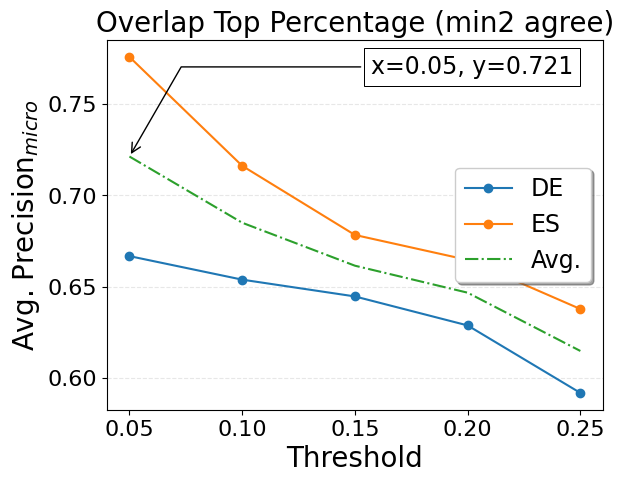

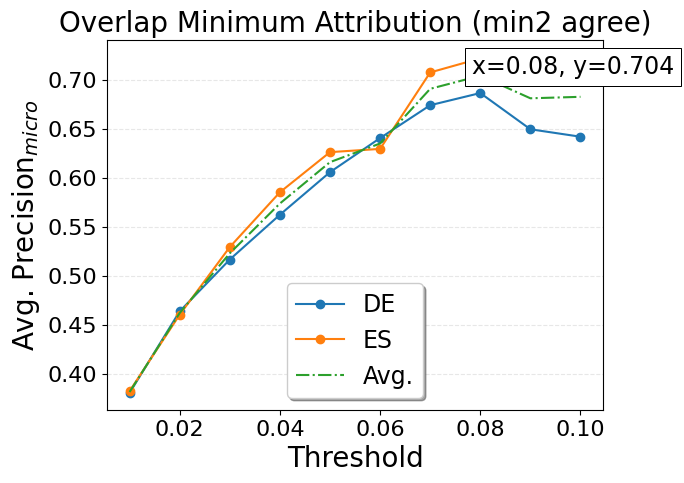

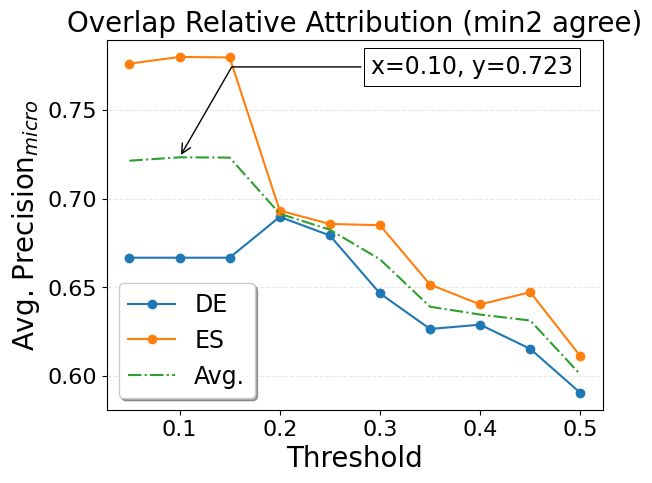

In [ ]:
## Top Percentage
fig, ax = plt.subplots()
ax.plot(min2_top_percentage_DE_threshold, min2_top_percentage_DE_precision, marker='o')
ax.plot(min2_top_percentage_DE_threshold, min2_top_percentage_ES_precision, marker='o')
ax.plot(min2_top_percentage_DE_threshold, min2_top_percentage_precision_avg, '-.')
plt.title('Overlap Top Percentage (min2 agree)', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{micro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='center right', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min2_top_percentage_DE_threshold, min2_top_percentage_precision_avg)

plt.savefig("micro_machine-human-min2-overlap_top_percentage_DE-ES.jpg")
plt.show()
print("")


## Minimum Attribution Score
fig, ax = plt.subplots()
ax.plot(min2_min_attribution_DE_threshold, min2_min_attribution_DE_precision, marker='o')
ax.plot(min2_min_attribution_ES_threshold, min2_min_attribution_ES_precision, marker='o')
ax.plot(min2_min_attribution_DE_threshold, min2_min_attribution_precision_avg, '-.')
plt.title('Overlap Minimum Attribution (min2 agree)', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{micro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower center', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="center", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min2_min_attribution_DE_threshold, min2_min_attribution_precision_avg)

plt.savefig("micro_machine-human-min2-overlap_min_attribution_DE-ES.jpg")
plt.show()
print("")


## Relative Attribution Score
fig, ax = plt.subplots()
ax.plot(min2_relative_attribution_DE_threshold, min2_relative_attribution_DE_precision, marker='o')
ax.plot(min2_relative_attribution_ES_threshold, min2_relative_attribution_ES_precision, marker='o')
ax.plot(min2_relative_attribution_DE_threshold, min2_relative_attribution_precision_avg, '-.')
plt.title('Overlap Relative Attribution (min2 agree)', fontsize=20, fontweight='medium')
plt.xlabel('Threshold', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision$_{micro}$', fontsize=20, fontweight='medium')
plt.legend(['DE', 'ES', 'Avg.'], loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

def annot_max(x,y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = max(y)
    text= "x={:.2f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw, fontsize=17)

annot_max(min2_relative_attribution_DE_threshold, min2_relative_attribution_precision_avg)

plt.savefig("micro_machine-human-min2-overlap_relative_attribution_DE-ES.jpg")
plt.show()
print("")

# Linguistic Analysis

### Data Requirements

You will need the following Excel files (generated by previous scripts):

*   Normalised_attribution_scores_ES_sums_per_sentence_top_0.15.xlsx
*   Normalised_attribution_scores_DE_sums_per_sentence_top_0.15.xlsx
*   EN_source.xlsx
*   POS_data_relative15_ES.xlsx
*   POS_data_relative15_DE.xlsx



In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

### Utils Functions

In [ ]:
!python -m spacy download en_core_web_lg

In [ ]:
import pandas as pd
import spacy
import json
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Load spaCy English model
nlp = spacy.load('en_core_web_lg')


def find_target_tokens(doc, target_word):
    """Find target word tokens, handling multi-word targets like 'flight attendant'."""
    target_words = target_word.lower().split()

    if len(target_words) == 1:
        # Single word target
        for token in doc:
            if token.text.lower() == target_words[0]:
                return [token]
    else:
        # Multi-word target - find consecutive tokens
        for i in range(len(doc) - len(target_words) + 1):
            match = True
            for j, target_part in enumerate(target_words):
                if doc[i + j].text.lower() != target_part:
                    match = False
                    break
            if match:
                # Return all tokens that make up the target phrase
                return [doc[i + j] for j in range(len(target_words))]

    return []


def find_salient_token(doc, salient_word):
    """Find salient word token, handling punctuation, contractions, and hyphenated words."""
    salient_lower = salient_word.lower().strip()

    # Try exact match first
    for token in doc:
        if token.text.lower() == salient_lower:
            return token

    # Try matching with lemma (base form)
    for token in doc:
        if token.lemma_.lower() == salient_lower:
            return token

    # Handle hyphenated words by finding token sequences
    if '-' in salient_lower:
        hyphen_result = find_hyphenated_sequence(doc, salient_lower)
        if hyphen_result:
            return hyphen_result

    # Handle contractions and possessives by finding token sequences
    if "'" in salient_lower:
        contraction_result = find_contraction_sequence(doc, salient_lower)
        if contraction_result:
            return contraction_result

    # More comprehensive matching for other cases
    for token in doc:
        token_text = token.text.lower()

        # 1. Clean token by removing trailing punctuation
        token_clean = token_text.rstrip('.,!?;:"\'()[]{}')
        if token_clean == salient_lower:
            return token

        # 2. Handle single letters (like 'C')
        if len(salient_lower) == 1:
            if token_clean == salient_lower:
                return token
            # For single letters, also check if token starts with the letter
            if token_text.startswith(salient_lower) and len(token_clean) == 1:
                return token
            # Special case: look for "D.C" when looking for "C"
            if salient_lower == 'c' and ('d.c' in token_text or 'dc' in token_clean):
                return token

        # 3. Try matching by removing all punctuation from both
        import string
        salient_no_punct = salient_lower.translate(str.maketrans('', '', string.punctuation))
        token_no_punct = token_text.translate(str.maketrans('', '', string.punctuation))
        if salient_no_punct and token_no_punct and salient_no_punct == token_no_punct:
            return token

    return None

def find_hyphenated_sequence(doc, hyphenated_word):
    """Find a sequence of tokens that make up a hyphenated word."""
    parts = hyphenated_word.split('-')

    for i in range(len(doc) - (len(parts) * 2 - 1) + 1):
        match = True
        token_idx = i

        for j, part in enumerate(parts):
            if token_idx >= len(doc) or doc[token_idx].text.lower() != part.lower():
                match = False
                break

            token_idx += 1

            if j < len(parts) - 1:
                if token_idx >= len(doc) or doc[token_idx].text != '-':
                    match = False
                    break
                token_idx += 1

        if match:
            return doc[i]

    return None

def find_contraction_sequence(doc, contraction_word):
    """Find a sequence of tokens that make up a contraction or possessive."""
    contraction_lower = contraction_word.lower()

    if contraction_lower.endswith("'s"):
        base_word = contraction_lower[:-2]
        result = find_word_apostrophe_sequence(doc, base_word, "'s")
        if result:
            return result
        # Fallback: just find the base word
        return find_base_word_fallback(doc, base_word)

    elif contraction_lower.endswith("'m"):
        base_word = contraction_lower[:-2]
        result = find_word_apostrophe_sequence(doc, base_word, "'m")
        if result:
            return result
        return find_base_word_fallback(doc, base_word)

    elif contraction_lower.endswith("'re"):
        base_word = contraction_lower[:-3]
        result = find_word_apostrophe_sequence(doc, base_word, "'re")
        if result:
            return result
        return find_base_word_fallback(doc, base_word)

    elif contraction_lower.endswith("'ll"):
        base_word = contraction_lower[:-3]
        result = find_word_apostrophe_sequence(doc, base_word, "'ll")
        if result:
            return result
        return find_base_word_fallback(doc, base_word)

    elif contraction_lower.endswith("'ve"):
        base_word = contraction_lower[:-3]
        result = find_word_apostrophe_sequence(doc, base_word, "'ve")
        if result:
            return result
        return find_base_word_fallback(doc, base_word)

    elif contraction_lower.endswith("'d"):
        base_word = contraction_lower[:-2]
        result = find_word_apostrophe_sequence(doc, base_word, "'d")
        if result:
            return result
        return find_base_word_fallback(doc, base_word)

    return None


def find_base_word_fallback(doc, base_word):
    """Fallback function to find just the base word if contraction sequence fails."""
    print(f"  DEBUG: Falling back to finding just base word '{base_word}'")

    for token in doc:
        if token.text.lower() == base_word.lower():
            print(f"  DEBUG: Found base word fallback: '{token.text}' (POS: {token.pos_})")
            return token

    print(f"  DEBUG: Base word fallback failed for '{base_word}'")
    return None

def find_word_apostrophe_sequence(doc, base_word, apostrophe_part):
    """Find a sequence like ['word', \"'s\"] or ['I', \"'m\"]."""
    # Debug: print what we're looking for and what's available
    print(f"  DEBUG: Looking for base_word='{base_word}' + apostrophe_part='{apostrophe_part}'")

    for i in range(len(doc) - 1):
        current_token = doc[i].text.lower()
        next_token = doc[i + 1].text

        print(f"  DEBUG: Checking tokens[{i}]='{doc[i].text}' (lower: '{current_token}') + tokens[{i+1}]='{doc[i + 1].text}' (repr: {repr(next_token)})")

        # Check if current token matches base word
        if current_token == base_word.lower():
            print(f"  DEBUG: Base word '{base_word}' matches token '{doc[i].text}'")

            # Now check apostrophe part - be very flexible with matching
            if (next_token == apostrophe_part or
                next_token.lower() == apostrophe_part.lower() or
                next_token == "'s" or  # regular apostrophe
                next_token == "'s" or  # smart quote
                next_token == "′s" or  # prime symbol
                next_token == "`s" or  # backtick
                (apostrophe_part.lower() == "'s" and next_token in ["'s", "'s", "′s", "`s"]) or
                (apostrophe_part.lower() == "'m" and next_token in ["'m", "'m", "′m", "`m"]) or
                (apostrophe_part.lower() == "'re" and next_token in ["'re", "'re", "′re", "`re"]) or
                (apostrophe_part.lower() == "'ll" and next_token in ["'ll", "'ll", "′ll", "`ll"]) or
                (apostrophe_part.lower() == "'ve" and next_token in ["'ve", "'ve", "′ve", "`ve"]) or
                (apostrophe_part.lower() == "'d" and next_token in ["'d", "'d", "′d", "`d"])):

                print(f"  DEBUG: Found match! Base='{doc[i].text}' + Apostrophe='{next_token}'")
                return doc[i]
            else:
                print(f"  DEBUG: Base word matches but apostrophe part '{next_token}' doesn't match expected '{apostrophe_part}'")

    print(f"  DEBUG: No match found for '{base_word}' + '{apostrophe_part}'")
    return None

### For max threshold Relative top 15% (per sentence) extract salient words and POS tags

In [ ]:
 def create_dicts_for_relative_top(EN_source, language_scores_excel):

  DE_dictionary = {}
  ES_dictionary = {}
  sentence_dict_ES = {}
  sentence_dict_DE = {}

  # Get all possible sheet names from both files to ensure we process all sentences
  all_sheet_names = set(ES_top15.keys()).union(set(DE_top15.keys()))

  # Compare each sheet
  for sheet_name in sorted(all_sheet_names):
      ES_exists = sheet_name in ES_top15
      DE_exists = sheet_name in DE_top15

      #if ES_exists and DE_exists:
      #    ES_df = ES_top15[sheet_name]
      #    DE_df = DE_top15[sheet_name]

      if ES_exists or DE_exists:
          ES_df = ES_top15[sheet_name] if ES_exists else None
          DE_df = DE_top15[sheet_name] if DE_exists else None

          ES_words = ES_df['Source_word'].values.tolist() if ES_df is not None else []
          DE_words = DE_df['Source_word'].values.tolist() if DE_df is not None else []
          ES_pos = ES_df['POS'].values.tolist() if ES_df is not None else []
          DE_pos = DE_df['POS'].values.tolist() if DE_df is not None else []

          # Create a fresh dict per sheet instead of reusing the same one
          sheet_ES_dict = {}
          sheet_DE_dict = {}

          for salient_word, pos in zip(ES_words, ES_pos):
              sheet_ES_dict[salient_word] = pos
          sentence_dict_ES[sheet_name] = sheet_ES_dict

          for salient_word, pos in zip(DE_words, DE_pos):
              sheet_DE_dict[salient_word] = pos
          sentence_dict_DE[sheet_name] = sheet_DE_dict

  print(f"\nsentence_dict_ES: {sentence_dict_ES}")
  print(f"sentence_dict_DE: {sentence_dict_DE}")
  ES_dict_length = 0
  for sentence, word_pos_dict in sentence_dict_ES.items():
    ES_dict_length += len(word_pos_dict)
  print(f"Number of salient words in ES dict: {ES_dict_length}")
  DE_dict_length = 0
  for sentence, word_pos_dict in sentence_dict_DE.items():
    DE_dict_length += len(word_pos_dict)
  print(f"Number of salient words in DE dict: {DE_dict_length}")


  combined_dict = {}
  for sheet_name in sorted(set(sentence_dict_ES.keys()).union(set(sentence_dict_DE.keys()))):
      combined_dict[sheet_name] = {}
      if sheet_name in sentence_dict_ES:
          combined_dict[sheet_name].update(sentence_dict_ES[sheet_name])
      if sheet_name in sentence_dict_DE:
          combined_dict[sheet_name].update(sentence_dict_DE[sheet_name])
  print(f"\nCombined dictionary: {combined_dict}")
  print(f"Number of sentences in combined dict: {len(combined_dict)}")
  combined_dict_length = 0
  for sentence, word_pos_dict in combined_dict.items():
    combined_dict_length += len(word_pos_dict)
  print(f"Number of salient words in combined dict: {combined_dict_length}\n")

  return sentence_dict_ES, sentence_dict_DE, combined_dict

In [ ]:
EN_source = pd.read_excel('EN_source.xlsx')
ES_top15 = pd.read_excel('Normalised_attribution_scores_ES_sums_per_sentence_top_0.15.xlsx', sheet_name=None)
DE_top15 = pd.read_excel('Normalised_attribution_scores_DE_sums_per_sentence_top_0.15.xlsx', sheet_name=None)


sentence_dict_ES, sentence_dict_DE, combined_dict = create_dicts_for_relative_top(EN_source, ES_top15)

def write_dicts_to_excel(dictionary, language):
  # Map each sheet_name to its list of salient words
  salient_words_map = {
      sheet_name: list(word_pos_dict.keys())
      for sheet_name, word_pos_dict in dictionary.items()
  }
  print(salient_words_map)

  POS_map = {
      sheet_name: list(word_pos_dict.values())
      for sheet_name, word_pos_dict in dictionary.items()
  }
  print(POS_map)


  EN_source[f'salient_words_{language}'] = EN_source['ID'].map(
      lambda x: '; '.join(str(item) for item in salient_words_map.get(f'Sent_{x}', []))
  )

  EN_source[f'POS_{language}'] = EN_source['ID'].map(
      lambda x: '; '.join(str(item) for item in POS_map.get(f'Sent_{x}', []))
  )

  # Add as new column by matching the sentence identifier column in EN_source
  print(EN_source[EN_source[f'salient_words_{language}'].isna()]['ID'].unique())
  print(EN_source[EN_source[f'POS_{language}'].isna()]['ID'].unique())

  print(EN_source)
  EN_source.to_excel(f"POS_data_relative15_{language}.xlsx")
  print(f"\nSaved to excel.")

write_dicts_to_excel(combined_dict, "DE_ES")

In [ ]:
ES_df = pd.read_excel("POS_data_relative15_ES.xlsx")
DE_df = pd.read_excel("POS_data_relative15_DE.xlsx")

combined_df = pd.merge(ES_df, DE_df, on=["ID", "target_word", "EN_source"])
combined_df = combined_df.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
print(combined_df)

combined_df.to_excel("POS_data_relative15_DE_ES_combined.xlsx")

## POS Analysis

### POS Combined DE-ES

In [ ]:
def calculate_average_pos_percentage(data):
    """
    Calculate POS tag percentages per all words / per salient words.

    Parameters:
    - data: Requires 'POS_data_relative15_DE_ES_combined.xlsx' file with relevant columns.
    """
    all_pos_counts_all = Counter()
    all_pos_counts_labeled_DE = Counter()
    all_pos_counts_labeled_ES = Counter()

    total_processed = 0
    total_found_DE = 0
    total_found_ES = 0
    total_overall_found = 0
    total_not_found_DE = 0
    total_not_found_ES = 0

    salient_words_both_in_DE_ES = []

    for index, row in data.iterrows():
        text = row['EN_source']
        salient_words_str_DE = row.get('salient_words_DE', '')
        salient_words_str_ES = row.get('salient_words_ES', '')
        #print(text)  # Text is the English source sentence

        total_processed += 1

        # Parse the text with spaCy
        doc = nlp(text)

        # Count all POS tags in the text
        for token in doc:
            if not token.is_space:  # Skip whitespace tokens
                pos_label = token.pos_
                all_pos_counts_all[pos_label] += 1
                total_overall_found += 1
                #print(f"Token --{token}-- has POS label --{pos_label}--")


        # Skip if any required field is missing or empty
        if pd.isna(salient_words_str_DE) and pd.isna(salient_words_str_ES):
            continue

        # Split salient words by semicolon and clean them
        salient_words_list_DE = [word.strip() for word in salient_words_str_DE.split(';') if word.strip()] if isinstance(salient_words_str_DE, str) else []
        salient_words_list_ES = [word.strip() for word in salient_words_str_ES.split(';') if word.strip()] if isinstance(salient_words_str_ES, str) else []

        for salient_word_DE, salient_word_ES in zip(salient_words_list_DE, salient_words_list_ES):
            if salient_word_DE == salient_word_ES:
                salient_words_both_in_DE_ES.append(salient_word_DE)

        # For each salient word, find it in the text and count its POS
        for salient_word in salient_words_list_DE:
            salient_token = find_salient_token(doc, salient_word)

            if salient_token:
                pos_label = salient_token.pos_
                all_pos_counts_labeled_DE[pos_label] += 1
                total_found_DE += 1
                #print(f"Salient word --{salient_token}-- with POS --{pos_label}--")
            else:
                total_not_found_DE += 1
                print(f"Salient word '{salient_word}' not found in text: {text[:50]}...")

                # Enhanced debugging for contractions
                if "'" in salient_word:
                    print(f"  DEBUG: Apostrophe word - analyzing tokenization...")
                    tokens_with_indices = [(i, token.text, repr(token.text)) for i, token in enumerate(doc)]
                    print(f"  DEBUG: All tokens with repr: {tokens_with_indices}")

                    # Show character codes for apostrophe characters
                    for char in salient_word:
                        if char in "''′`":
                            print(f"  DEBUG: Apostrophe character '{char}' has Unicode code: {ord(char)}")

                # Show available tokens
                tokens_in_text = [token.text for token in doc]
                print(f"  Available tokens: {tokens_in_text}")
                similar_tokens = [token.text for token in doc if salient_word.lower().replace("'", "").replace("'", "") in token.text.lower() or token.text.lower() in salient_word.lower().replace("'", "").replace("'", "")]
                if similar_tokens:
                    print(f"  Similar tokens found: {similar_tokens}")

        for salient_word in salient_words_list_ES:
            salient_token = find_salient_token(doc, salient_word)

            if salient_token:
                pos_label = salient_token.pos_
                all_pos_counts_labeled_ES[pos_label] += 1
                total_found_ES += 1
                #print(f"Salient word --{salient_token}-- with POS --{pos_label}--")
            else:
                total_not_found_ES += 1
                print(f"Salient word '{salient_word}' not found in text: {text[:50]}...")

                # Enhanced debugging for contractions
                if "'" in salient_word:
                    print(f"  DEBUG: Apostrophe word - analyzing tokenization...")
                    tokens_with_indices = [(i, token.text, repr(token.text)) for i, token in enumerate(doc)]
                    print(f"  DEBUG: All tokens with repr: {tokens_with_indices}")

                    # Show character codes for apostrophe characters
                    for char in salient_word:
                        if char in "''′`":
                            print(f"  DEBUG: Apostrophe character '{char}' has Unicode code: {ord(char)}")

                # Show available tokens
                tokens_in_text = [token.text for token in doc]
                print(f"  Available tokens: {tokens_in_text}")
                similar_tokens = [token.text for token in doc if salient_word.lower().replace("'", "").replace("'", "") in token.text.lower() or token.text.lower() in salient_word.lower().replace("'", "").replace("'", "")]
                if similar_tokens:
                    print(f"  Similar tokens found: {similar_tokens}")


    print("\nPOS Tags and Frequency")

    # Calculate percentages for each POS tag of all words
    pos_percentages_all = {}
    print(f"All POS counts all: {all_pos_counts_all}")
    print(f"Total overall found: {total_overall_found}")
    for pos in all_pos_counts_all:
        #print(f"POS: {pos}")
        #print(f"Total count: {total_count}")
        labeled_count = all_pos_counts_all[pos]
        #print(f"Labeled count: {labeled_count}")
        percentage = (labeled_count / total_overall_found) * 100 if total_overall_found > 0 else 0
        pos_percentages_all[pos] = percentage
        print(f"{pos}: {labeled_count}/{total_overall_found} = {percentage:.2f}%")
    print("")

    # Calculate percentages for each POS tag among salient words
    pos_percentages_salient_DE = {}
    pos_percentages_salient_ES = {}
    print(f"All salient counts DE: {all_pos_counts_labeled_DE}")
    print(f"Total salient found DE: {total_found_DE}")
    for pos in all_pos_counts_labeled_DE:
        labeled_count = all_pos_counts_labeled_DE[pos]
        percentage = (labeled_count / total_found_DE) * 100 if total_found_DE > 0 else 0
        pos_percentages_salient_DE[pos] = percentage
        print(f"For DE: {pos}: {labeled_count}/{total_found_DE} = {percentage:.2f}%")

    print(f"All salient counts ES: {all_pos_counts_labeled_ES}")
    print(f"Total salient found ES: {total_found_ES}")
    for pos in all_pos_counts_labeled_ES:
        labeled_count = all_pos_counts_labeled_ES[pos]
        percentage = (labeled_count / total_found_ES) * 100 if total_found_ES > 0 else 0
        pos_percentages_salient_ES[pos] = percentage
        print(f"For ES: {pos}: {labeled_count}/{total_found_ES} = {percentage:.2f}%")

    print(f"\nSummary:")
    print(f"Total rows processed: {total_processed}")
    print(f"Salient words both in DE and ES: {salient_words_both_in_DE_ES}")
    print(f"Number of salient words both in DE and ES: {len(salient_words_both_in_DE_ES)}")
    print(f"Total salient words found DE: {total_found_DE}")
    print(f"Total salient words found ES: {total_found_ES}")
    print(f"Total salient words not found DE: {total_not_found_DE}")
    print(f"Total salient words not found ES: {total_not_found_ES}")
    print(f"Total POS tags for all words in the texts: {sum(all_pos_counts_all.values())}")
    print(f"Total POS tags of salient words DE: {sum(all_pos_counts_labeled_DE.values())}")
    print(f"Total POS tags of salient words ES: {sum(all_pos_counts_labeled_ES.values())}")

    # Display results in a bar chart
    print("\n")
    display_average_pos_chart(pos_percentages_salient_DE, pos_percentages_salient_ES, pos_percentages_all, title="POS Tag Distribution of Salient Words", show_percent_symbol=False)


    return pos_percentages_all, pos_percentages_salient_DE, pos_percentages_salient_ES, all_pos_counts_all


def display_average_pos_chart(pos_percentages_DE, pos_percentages_ES, pos_percentages_a, title, show_percent_symbol=True):
    filtered_data_DE = {pos: perc for pos, perc in pos_percentages_DE.items() if perc > 0}
    filtered_data_ES = {pos: perc for pos, perc in pos_percentages_ES.items() if perc > 0}
    all_pos = {pos_all: perc_all for pos_all, perc_all in pos_percentages_a.items() if perc_all > 0}

    if not filtered_data_DE or not filtered_data_ES:
        print("No POS tags found for salient words")
        return

    # Keep only common keys and remove DET
    common_keys = set(filtered_data_DE.keys()) & set(filtered_data_ES.keys()) & set(all_pos.keys())
    for d in [filtered_data_DE, filtered_data_ES, all_pos]:
        d.pop("DET", None)
    common_keys.discard("DET")

    filtered_data_DE = {k: v for k, v in filtered_data_DE.items() if k in common_keys}
    filtered_data_ES = {k: v for k, v in filtered_data_ES.items() if k in common_keys}
    all_pos          = {k: v for k, v in all_pos.items() if k in common_keys}

    # Sort by DE values
    sorted_labels = [k for k, v in sorted(filtered_data_ES.items(), key=lambda x: x[1], reverse=True)]
    values_DE  = [filtered_data_DE[k] for k in sorted_labels]
    values_ES  = [filtered_data_ES[k] for k in sorted_labels]
    values_all = [all_pos[k] for k in sorted_labels]

    x = np.arange(len(sorted_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 8))

    bars_DE = ax.barh(x + width/2, values_DE, width, color='#f97316', alpha=0.8, edgecolor='black', label='DE')
    bars_ES = ax.barh(x - width/2, values_ES, width, color='#06b6d4', alpha=0.8, edgecolor='black', label='ES')

    # Add percentage labels on bars
    for bar, value in zip(bars_DE, values_DE):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{value:.1f}%', ha='left', va='center', fontweight='bold', fontsize=20)

    for bar, value in zip(bars_ES, values_ES):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{value:.1f}%', ha='left', va='center', fontweight='bold', fontsize=20)

    # Add red vertical lines for all-words baseline
    for i, all_value in enumerate(values_all):
        ax.plot(
            [all_value, all_value],
            [x[i] - width, x[i] + width],
            color='red', linewidth=2.5, zorder=5
        )

    # Set y-axis labels
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_labels, fontsize=20)

    ax.set_title(title, fontsize=24, fontweight='medium')
    ax.set_xlabel("Percentage of Salient Words with this POS Tag (%)", fontsize=24, fontweight='medium')
    ax.set_ylabel("POS Tags", fontsize=24, fontweight='medium')
    ax.tick_params(axis='both', which='major', labelsize=22)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=2.5, label='Baseline: all words')
    ]
    ax.legend(handles=[*ax.get_legend_handles_labels()[0], *legend_elements], fontsize=18)

    ax.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig("POS_distribution_salient_words_DE-ES.jpg")
    plt.show()

Data shape: (60, 8)
Columns: ['Unnamed: 0', 'ID', 'target_word', 'EN_source', 'salient_words_ES', 'POS_ES', 'salient_words_DE', 'POS_DE']

First few rows of relevant columns:
                                           EN_source       target_word  \
0  What you should never do on a plane: Flight at...  flight attendant   
1  In an Instagram video posted last month, the "...          musician   
2  On Thursday evening, finally, she stepped out ...          opponent   
3  The socialite who got a countess to write a 50...         socialite   
4  Kensington massage therapist jailed for sexual...         therapist   

  salient_words_DE POS_DE salient_words_ES POS_ES  
0          reveals   VERB          reveals   VERB  
1    collaborating   VERB    collaborating   VERB  
2              her   PRON              top   NOUN  
3         countess   NOUN         countess   NOUN  
4       Kensington  PROPN       Kensington  PROPN  

CALCULATING POS TAG PERCENTAGES
  DEBUG: Looking for base_word='who

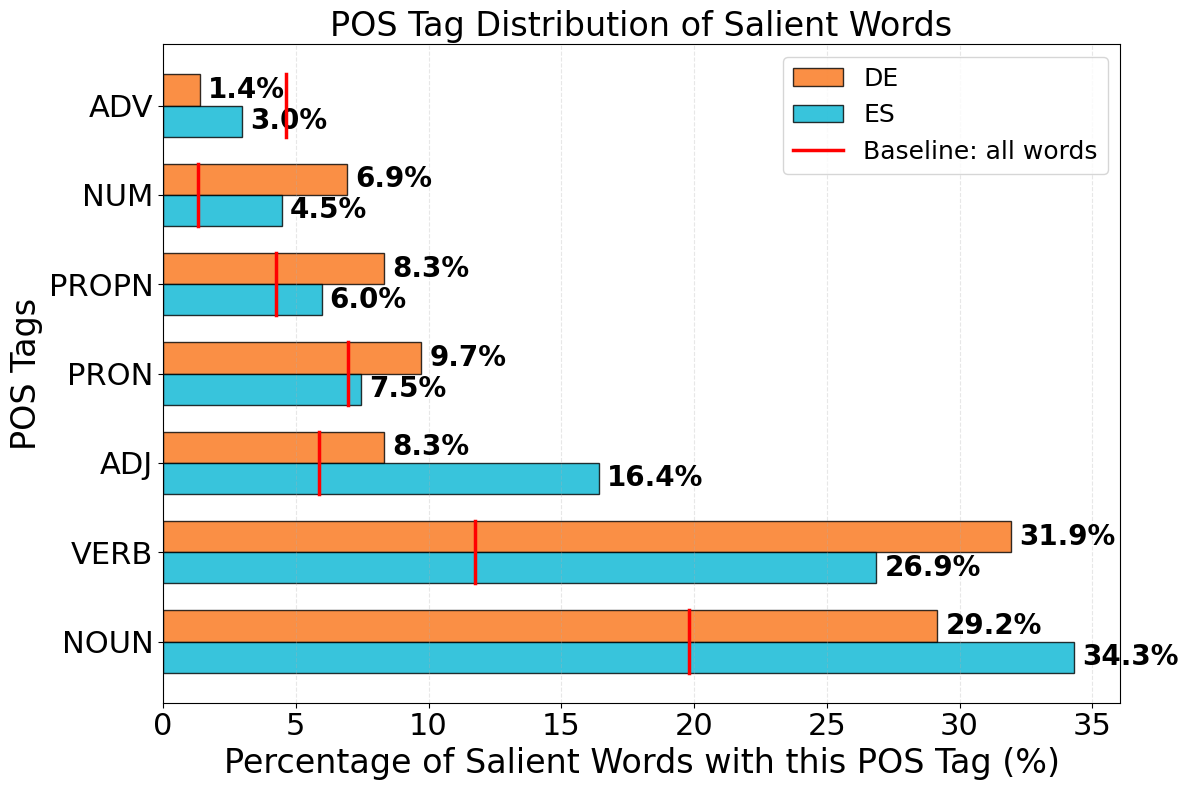

In [ ]:
# Load the data from a tab-separated text file
data = pd.read_excel('POS_data_relative15_DE_ES_combined.xlsx')

# Display basic info about the data
print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print("\nFirst few rows of relevant columns:")
print(data[['EN_source', 'target_word', 'salient_words_DE', 'POS_DE', 'salient_words_ES', 'POS_ES']].head())


print("\n" + "="*50)
print("CALCULATING POS TAG PERCENTAGES")
print("="*50)

# Run function to calculate POS frequency distribution among salient words
pos_percentages_all, pos_percentages_salient_DE, pos_percentages_salient_ES, all_pos_counts_all = calculate_average_pos_percentage(data)

## Dependency Distance Analysis

### POS Combined DE-ES

In [ ]:
def avg_dependencies_distance_combined(data):
    all_distances = []
    salient_distances_DE = []
    salient_distances_ES = []

    for index, row in data.iterrows():
        text = row['EN_source']
        #print(text)
        target_word = row['target_word'] # Renamed to avoid confusion with spaCy token
        salient_words_str_DE = row.get('salient_words_DE', '')  # Get salient words string
        salient_words_str_ES = row.get('salient_words_ES', '')  # Get salient words string

        # Skip if any required field is missing or empty
        if pd.isna(text) or pd.isna(target_word) or pd.isna(salient_words_str_DE) or pd.isna(salient_words_str_ES):
            continue

        doc = nlp(text)

        target_tokens = find_target_tokens(doc, target_word)

        if not target_tokens:
            print(f"Target word '{target_word}' not found in text: {text[:50]}...")
            continue

        # Collect all non-target tokens (as spaCy Token objects)
        non_target_tokens = []
        for token in doc:
            # Check if the current token is one of the target tokens
            # Compare by index for exact token match, and also skip spaces
            is_target_token = False
            for tt in target_tokens:
                if token.i == tt.i:
                    is_target_token = True
                    break
            if not is_target_token and not token.is_space:
                non_target_tokens.append(token)

        #print(f"Non target tokens: {non_target_tokens}")

        # Calculate distances from each non-target token to each target token
        for non_target_token in non_target_tokens:
            #print(f"Non target token: {non_target_token}")
            for target_tok in target_tokens:
                #print(f"Target token: {target_tok}")
                distance = find_distance(target_tok, non_target_token, doc)
                #print(f"Distance from '{non_target_token}' to '{target_tok}': {distance}")
                if distance is not None and distance > 0: # Only add valid positive distances
                    all_distances.append(distance)


        # Split salient words by semicolon and clean them
        salient_words_list_DE = [word.strip() for word in salient_words_str_DE.split(';') if word.strip()]
        salient_words_list_ES = [word.strip() for word in salient_words_str_ES.split(';') if word.strip()]

        ## DE ##
        # For each salient word, find it in the text and calculate distance
        for salient_word in salient_words_list_DE:
            # Find the salient word token in the document
            salient_token = find_salient_token(doc, salient_word)

            # If salient word is found, calculate distance to each target token
            if salient_token:
                for target_token in target_tokens:
                    distance = find_distance(target_token, salient_token, doc)
                    if distance is not None and distance > 0:
                        #print(f"Distance from '{salient_token}' to '{target_token}': {distance}")
                        salient_distances_DE.append(distance)
            else:
                # Debug: show what tokens are actually in the text around the expected word
                print(f"Salient word '{salient_word}' not found in text: {text[:50]}...")
                # Show all tokens for debugging
                tokens_in_text = [token.text for token in doc]
                print(f"  Available tokens: {tokens_in_text}")
                # Try to find similar tokens
                similar_tokens = [token.text for token in doc if salient_word.lower() in token.text.lower() or token.text.lower() in salient_word.lower()]
                if similar_tokens:
                    print(f"  Similar tokens found: {similar_tokens}")


        ## ES ##
        # For each salient word, find it in the text and calculate distance
        for salient_word in salient_words_list_ES:
            # Find the salient word token in the document
            salient_token = find_salient_token(doc, salient_word)

            # If salient word is found, calculate distance to each target token
            if salient_token:
                for target_token in target_tokens:
                    distance = find_distance(target_token, salient_token, doc)
                    if distance is not None and distance > 0:
                        #print(f"Distance from '{salient_token}' to '{target_token}': {distance}")
                        salient_distances_ES.append(distance)
            else:
                # Debug: show what tokens are actually in the text around the expected word
                print(f"Salient word '{salient_word}' not found in text: {text[:50]}...")
                # Show all tokens for debugging
                tokens_in_text = [token.text for token in doc]
                print(f"  Available tokens: {tokens_in_text}")
                # Try to find similar tokens
                similar_tokens = [token.text for token in doc if salient_word.lower() in token.text.lower() or token.text.lower() in salient_word.lower()]
                if similar_tokens:
                    print(f"  Similar tokens found: {similar_tokens}")


    # Turn the list of all distances into a dictionary with distances and their frequencies
    average_distance_frequency_all = {}
    average_distance_frequency_salient_DE = {}
    average_distance_frequency_salient_ES = {}

    # Calculate average frequency for each distance (dividing by total number of rows)
    # For all other tokens
    distance_frequency_all = Counter(all_distances)
    for distance, count in distance_frequency_all.items():
        #print(f"Distance: {distance}, Frequency: {count}")
        average_distance_frequency_all[distance] = count / len(all_distances)

    ## DE ##
    # For salient - target tokens
    distance_frequency_salient_DE = Counter(salient_distances_DE)
    for distance, count in distance_frequency_salient_DE.items():
        #print(f"Distance: {distance}, Frequency: {count}")
        average_distance_frequency_salient_DE[distance] = count / len(salient_distances_DE)

    ## ES ##
    # For salient - target tokens
    distance_frequency_salient_ES = Counter(salient_distances_ES)
    for distance, count in distance_frequency_salient_ES.items():
        #print(f"Distance: {distance}, Frequency: {count}")
        average_distance_frequency_salient_ES[distance] = count / len(salient_distances_ES)

    #average_distance_frequency = {distance: count / total_entries for distance, count in distance_frequency.items()}

    print(f"\nTotal distances calculated (all non-target words): {len(all_distances)}")
    print(f"Distance frequency for all: {dict(distance_frequency_all)}")
    print(f"Average distance frequency for all: {dict(average_distance_frequency_all)}")
    print(f"\nDE: Total distances calculated (salient-target words): {len(salient_distances_DE)}")
    print(f"DE: Distance frequency for salient-target: {dict(distance_frequency_salient_DE)}")
    print(f"DE: Average distance frequency for salient-target: {dict(average_distance_frequency_salient_DE)}")
    print(f"\nES: Total distances calculated (salient-target words): {len(salient_distances_ES)}")
    print(f"ES: Distance frequency for salient-target: {dict(distance_frequency_salient_ES)}")
    print(f"ES: Average distance frequency for salient-target: {dict(average_distance_frequency_salient_ES)}")

    print("\n")
    # Display the chart
    # The display_dep_freq_chart function is already defined in a previous cell.
    #display_dep_freq_chart(average_distance_frequency_all)
    display_dep_freq_chart(average_distance_frequency_salient_DE, average_distance_frequency_salient_ES, average_distance_frequency_all)


def find_distance(word1, word2, doc):
    """Calculate distance in the dependency tree."""

    # Create a mapping of token index to its head (parent) index
    token_to_head = {token.i: token.head.i for token in doc}

    # Function to find the path from a word to the root
    def get_path_to_root(token_idx):
        path = []
        visited = set()  # Prevent infinite loops
        while token_idx != token_to_head[token_idx] and token_idx not in visited:
            visited.add(token_idx)
            path.append(token_idx)
            token_idx = token_to_head[token_idx]
        path.append(token_idx)
        return path

    # Get the paths from both words to the root
    path1 = get_path_to_root(word1.i)
    path2 = get_path_to_root(word2.i)

    # Find the common ancestor
    common_ancestor = None
    for token in path1:
        if token in path2:
            common_ancestor = token
            break

    # Calculate distance only if common ancestor is found in both paths
    if common_ancestor is not None and common_ancestor in path1 and common_ancestor in path2:
        distance = path1.index(common_ancestor) + path2.index(common_ancestor)
        return distance
    else:
        # Handle case where common ancestor is not found
        return None


# PLOT the distances and frequencies
def display_dep_freq_chart(distance_frequency_salient_DE, distance_frequency_salient_ES, distance_frequency_all):
    # Get the union of all distances across all three datasets
    all_keys = sorted(set(distance_frequency_all.keys()) |
                      set(distance_frequency_salient_DE.keys()) |
                      set(distance_frequency_salient_ES.keys()))
    all_keys = [k for k in all_keys if k and k != 0]

    if not all_keys:
        print("No valid distances to plot")
        return

    # Align all datasets to the same keys (fill missing with 0)
    values_all = [distance_frequency_all.get(k, 0) for k in all_keys]
    values_DE  = [distance_frequency_salient_DE.get(k, 0) for k in all_keys]
    values_ES  = [distance_frequency_salient_ES.get(k, 0) for k in all_keys]

    x = np.arange(len(all_keys))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 8))

    bars_DE = ax.bar(x + width/2, values_DE, width, color='#f97316', alpha=0.8, edgecolor='black', label='DE')
    bars_ES = ax.bar(x - width/2, values_ES, width, color='#06b6d4', alpha=0.8, edgecolor='black', label='ES')

    # Add percentage labels on bars (skip zeros)
    #for bar, value in zip(bars_DE, values_DE):
    #    if value > 0:
    #        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
    #                f'{value:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

    #for bar, value in zip(bars_ES, values_ES):
    #    if value > 0:
    #        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
    #                f'{value:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

    # Add red vertical lines for all-words baseline
    for i, all_value in enumerate(values_all):
        ax.plot(
            [x[i] - width, x[i] + width],
            [all_value, all_value],
            color='red', linewidth=2.5, zorder=5
        )

    ax.set_xticks(x)
    ax.set_xticklabels(all_keys, fontsize=20)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=2.5, label='Baseline: all words to referent'),
        plt.Rectangle((0,0),1,1, color='#f97316', alpha=0.8, label='DE'),
        plt.Rectangle((0,0),1,1, color='#06b6d4', alpha=0.8, label='ES'),
    ]
    ax.legend(handles=legend_elements, fontsize=20)

    ax.set_title("Average Dependency Distances & Frequencies", fontsize=24, fontweight='medium')
    ax.set_xlabel("Distances in the Dependency Tree", fontsize=24, fontweight='medium')
    ax.set_ylabel("Average Frequency", fontsize=24, fontweight='medium')
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig("dependency_distances_salient_words_DE-ES_comparison.jpg")
    plt.show()

Data shape: (60, 8)
Columns: ['Unnamed: 0', 'ID', 'target_word', 'EN_source', 'salient_words_ES', 'POS_ES', 'salient_words_DE', 'POS_DE']

First few rows of relevant columns:
                                           EN_source       target_word  \
0  What you should never do on a plane: Flight at...  flight attendant   
1  In an Instagram video posted last month, the "...          musician   
2  On Thursday evening, finally, she stepped out ...          opponent   
3  The socialite who got a countess to write a 50...         socialite   
4  Kensington massage therapist jailed for sexual...         therapist   

  salient_words_ES salient_words_DE  
0          reveals          reveals  
1    collaborating    collaborating  
2              top              her  
3         countess         countess  
4       Kensington       Kensington   

  DEBUG: Looking for base_word='who' + apostrophe_part=''s'
  DEBUG: Checking tokens[0]='Who' (lower: 'who') + tokens[1]='’s' (repr: '’s')
  DEBUG: Ba

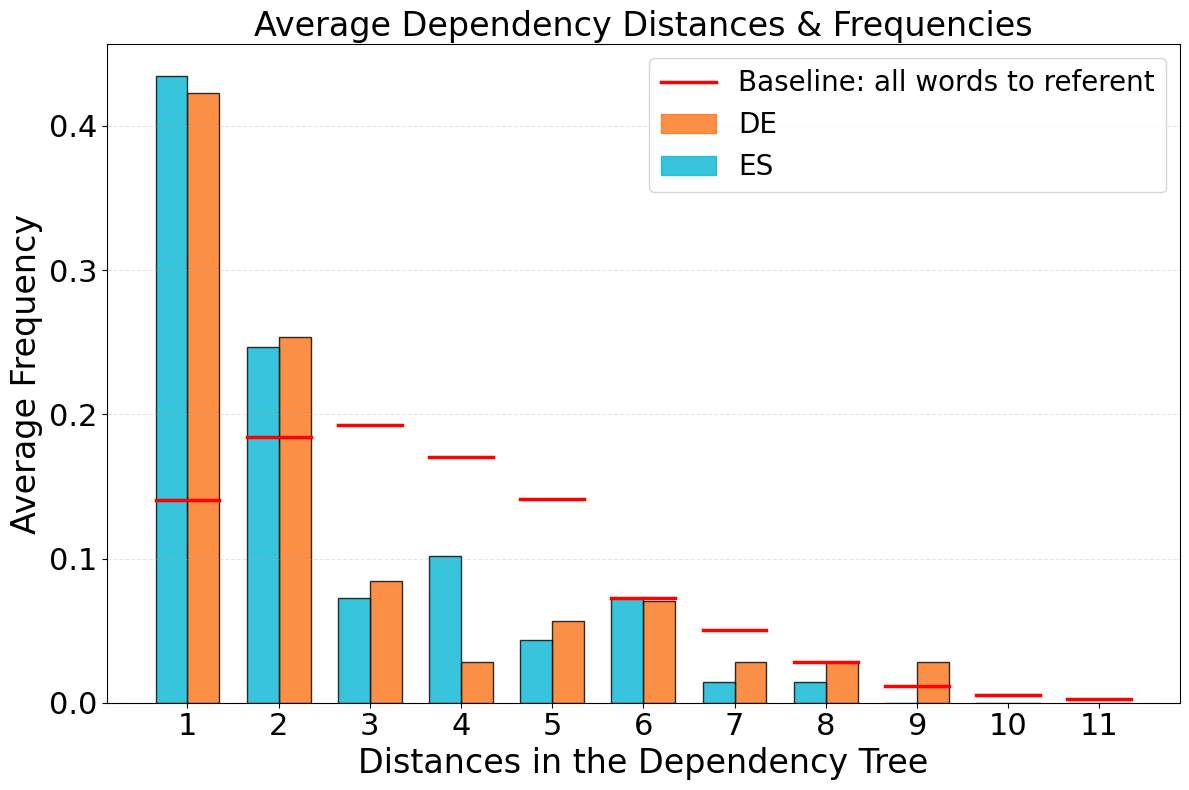

In [ ]:
# Load the data from a tab-separated text file
data = pd.read_excel('POS_data_relative15_DE_ES_combined.xlsx')

# Display basic info about the data
print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print("\nFirst few rows of relevant columns:")
print(data[['EN_source', 'target_word', 'salient_words_ES', 'salient_words_DE']].head(), "\n")

# Run function
avg_dependencies_distance_combined(data)

# Threshold visualisations for DE-ES Comparison (all annotators)

First run cells above (under all annotators and under min2 agree to access files and define lists)

In [ ]:
# Initialise all dictionaries
# 1. Top Percentage
DE_top_percentage_max = {}
ES_top_percentage_max = {}
DE_ES_top_percentage_max = {}
# 2. Top Word
DE_top_word_max = {}
ES_top_word_max = {}
DE_ES_top_word_max = {}
# 3. Minimum Attribution Sum
DE_min_attribution_max = {}
ES_min_attribution_max = {}
DE_ES_min_attribution_max = {}
# 4. Relative Attribution
DE_relative_attribution_max = {}
ES_relative_attribution_max = {}
DE_ES_relative_attribution_max = {}


# Write all max (threshold; precision) values to dictionaries
DE_top_percentage_max[top_percentage_DE_threshold[np.argmax(top_percentage_DE_precision)]] = max(top_percentage_DE_precision)
ES_top_percentage_max[top_percentage_DE_threshold[np.argmax(top_percentage_ES_precision)]] = max(top_percentage_ES_precision)
DE_ES_top_percentage_max[top_percentage_DE_threshold[np.argmax(top_percentage_precision_avg)]] = max(top_percentage_precision_avg)

DE_top_word_max[overlap_top_word_DE_threshold[np.argmax(overlap_top_word_DE_precision)]] = max(overlap_top_word_DE_precision)
ES_top_word_max[overlap_top_word_ES_threshold[np.argmax(overlap_top_word_ES_precision)]] = max(overlap_top_word_ES_precision)
DE_ES_top_word_max[overlap_top_word_ES_threshold[np.argmax(top_word_precision_avg)]] = max(top_word_precision_avg)

DE_min_attribution_max[min_attribution_DE_threshold[np.argmax(min_attribution_DE_precision)]] = max(min_attribution_DE_precision)
ES_min_attribution_max[min_attribution_ES_threshold[np.argmax(min_attribution_ES_precision)]] = max(min_attribution_ES_precision)
DE_ES_min_attribution_max[min_attribution_ES_threshold[np.argmax(min_attribution_precision_avg)]] = max(min_attribution_precision_avg)

DE_relative_attribution_max[relative_attribution_DE_threshold[np.argmax(relative_attribution_DE_precision)]] = max(relative_attribution_DE_precision)
ES_relative_attribution_max[relative_attribution_ES_threshold[np.argmax(relative_attribution_ES_precision)]] = max(relative_attribution_ES_precision)
DE_ES_relative_attribution_max[relative_attribution_ES_threshold[np.argmax(relative_attribution_precision_avg)]] = max(relative_attribution_precision_avg)

print(f"DE Top Percentage Max: {DE_top_percentage_max}")
print(f"ES Top Percentage Max: {ES_top_percentage_max}")
print(f"DE-ES Top Percentage Max: {top_percentage_precision_avg}\n")
print(f"DE Top Word Max: {DE_top_word_max}")
print(f"ES Top Word Max: {ES_top_word_max}")
print(f"DE-ES Top Word Max: {top_word_precision_avg}\n")
print(f"DE Min. Attribution Max: {DE_min_attribution_max}")
print(f"ES Min. Attribution Max: {ES_min_attribution_max}")
print(f"DE-ES Min. Attribution Max: {min_attribution_precision_avg}\n")
print(f"DE Relative Attribution Max: {DE_relative_attribution_max}")
print(f"ES Relative Attribution Max: {ES_relative_attribution_max}")
print(f"DE-ES Relative Attribution Max: {DE_ES_relative_attribution_max}\n")
print(min_attribution_DE_threshold)
print(min_attribution_DE_precision)
print(min_attribution_ES_precision)
print(min_attribution_precision_avg)
print()

approaches = ["1", "2", "3", "4"]

def to_approach_dict(*dicts):
    return {approach: list(d.values())[0] for approach, d in zip(approaches, dicts)}

top_scores_per_approach_DE    = to_approach_dict(DE_top_percentage_max, DE_top_word_max, DE_min_attribution_max, DE_relative_attribution_max)
top_scores_per_approach_ES    = to_approach_dict(ES_top_percentage_max, ES_top_word_max, ES_min_attribution_max, ES_relative_attribution_max)
top_scores_per_approach_DE_ES = to_approach_dict(DE_ES_top_percentage_max, DE_ES_top_word_max, DE_ES_min_attribution_max, DE_ES_relative_attribution_max)

print(f"----- Final dictionaries with top scores per approach: -----")
print(f"Top scores per approach DE: {top_scores_per_approach_DE}")
print(f"Top scores per approach ES: {top_scores_per_approach_ES}")
print(f"Top scores per approach DE-ES: {top_scores_per_approach_DE_ES}")

DE Top Percentage Max: {0.05: 0.8167}
ES Top Percentage Max: {0.05: 0.8793}
DE-ES Top Percentage Max: [0.848, 0.81635, 0.7884500000000001, 0.782, 0.7602]

DE Top Word Max: {0.25: 0.8167}
ES Top Word Max: {0.25: 0.8793}
DE-ES Top Word Max: [0.848]

DE Min. Attribution Max: {0.1: 0.791}
ES Min. Attribution Max: {0.1: 0.8308}
DE-ES Min. Attribution Max: [0.5277499999999999, 0.6035999999999999, 0.6543, 0.7125, 0.744, 0.75875, 0.78965, 0.79935, 0.79585, 0.8109]

DE Relative Attribution Max: {0.05: 0.8167}
ES Relative Attribution Max: {0.15: 0.8971}
DE-ES Relative Attribution Max: {0.15: 0.85135}

[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
[0.5334, 0.6082, 0.657, 0.7112, 0.7358, 0.7528, 0.7826, 0.7843, 0.7792, 0.791]
[0.5221, 0.599, 0.6516, 0.7138, 0.7522, 0.7647, 0.7967, 0.8144, 0.8125, 0.8308]
[0.5277499999999999, 0.6035999999999999, 0.6543, 0.7125, 0.744, 0.75875, 0.78965, 0.79935, 0.79585, 0.8109]

----- Final dictionaries with top scores per approach: -----
Top scores p

## Threshold Approaches 1-4

#### Micro

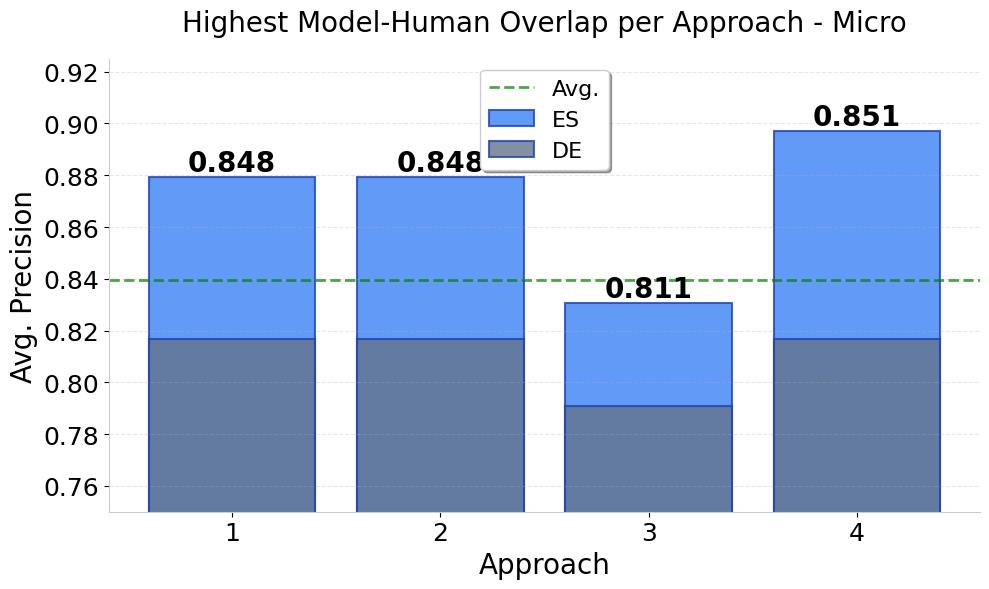


------Results for MICRO precision -------

Data Summary for max DE:
----------------------------------------
Score 1: 0.8167
Score 2: 0.8167
Score 3: 0.791
Score 4: 0.8167

Data Summary for max ES:
----------------------------------------
Score 1: 0.8793
Score 2: 0.8793
Score 3: 0.8308
Score 4: 0.8971

Data Summary for max avg DE-ES:
----------------------------------------
Score 1: 0.848
Score 2: 0.848
Score 3: 0.8109
Score 4: 0.85135

Peak Performance: 0.85135 at score 4
Lowest Performance: 0.8109 at score 3
Range: 0.8109% - 0.85135 (0.0404500000000001 score spread)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data_dict_DE = top_scores_per_approach_DE
data_dict_ES = top_scores_per_approach_ES
data_dict_DE_ES = top_scores_per_approach_DE_ES

# Extract x and y values
x_values_DE = list(data_dict_DE.keys())
y_values_DE = list(data_dict_DE.values())
x_values_ES = list(data_dict_ES.keys())
y_values_ES = list(data_dict_ES.values())
x_values_DE_ES = list(data_dict_DE_ES.keys())
y_values_DE_ES = list(data_dict_DE_ES.values())

average_overlap = np.mean(y_values_DE_ES)

# Create the bar chart
plt.figure(figsize=(10, 6))
bars_ES = plt.bar(x_values_ES, y_values_ES, color='#3b82f6', alpha=0.8, edgecolor='#1e40af', linewidth=1.5)
bars_DE = plt.bar(x_values_DE, y_values_DE, color='#64748b', alpha=0.8, edgecolor='#1e40af', linewidth=1.5)
#bars_DE_ES = plt.bar(x_values_DE_ES, y_values_DE_ES, color='#3b82f6', alpha=0.8, edgecolor='#1e40af', linewidth=1.5)

# Customize the chart
plt.title('Highest Model-Human Overlap per Approach - Micro',
          fontsize=20, fontweight='medium', pad=20)
plt.xlabel('Approach', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision', fontsize=20, fontweight='medium')
plt.tick_params(axis='both', which='major', labelsize=18)

# Add average line
plt.axhline(y=average_overlap, color='green', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Average ({average_overlap:.3f})')

# Add legend
plt.legend(["Avg.", "ES", "DE"], loc='upper center', frameon=True, fancybox=True, shadow=True, fontsize=16)


# Set y-axis limits for better visualization
plt.ylim(0.75, 0.925)

# Add value labels on top of each bar
for bar, value in zip(bars_ES, y_values_DE_ES):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{value:.3f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Customize appearance
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

# Adjust layout and display
plt.tight_layout()
plt.savefig("threshold_approaches_overlap_DE_ES.jpg")
plt.show()

# Optional: Save the figure
# plt.savefig('trigger_words_overlap_chart.png', dpi=300, bbox_inches='tight')

# Print summary statistics
print("\n------Results for MICRO precision -------")
print("\nData Summary for max DE:")
print("-" * 40)
for score, percentage in data_dict_DE.items():
    print(f"Score {score}: {percentage}")

print("\nData Summary for max ES:")
print("-" * 40)
for score, percentage in data_dict_ES.items():
    print(f"Score {score}: {percentage}")


print("\nData Summary for max avg DE-ES:")
print("-" * 40)
for score, percentage in data_dict_DE_ES.items():
    print(f"Score {score}: {percentage}")

print(f"\nPeak Performance: {max(y_values_DE_ES)} at score {x_values_DE_ES[y_values_DE_ES.index(max(y_values_DE_ES))]}")
print(f"Lowest Performance: {min(y_values_DE_ES)} at score {x_values_DE_ES[y_values_DE_ES.index(min(y_values_DE_ES))]}")
print(f"Range: {min(y_values_DE_ES)}% - {max(y_values_DE_ES)} ({max(y_values_DE_ES) - min(y_values_DE_ES)} score spread)")

#### Macro

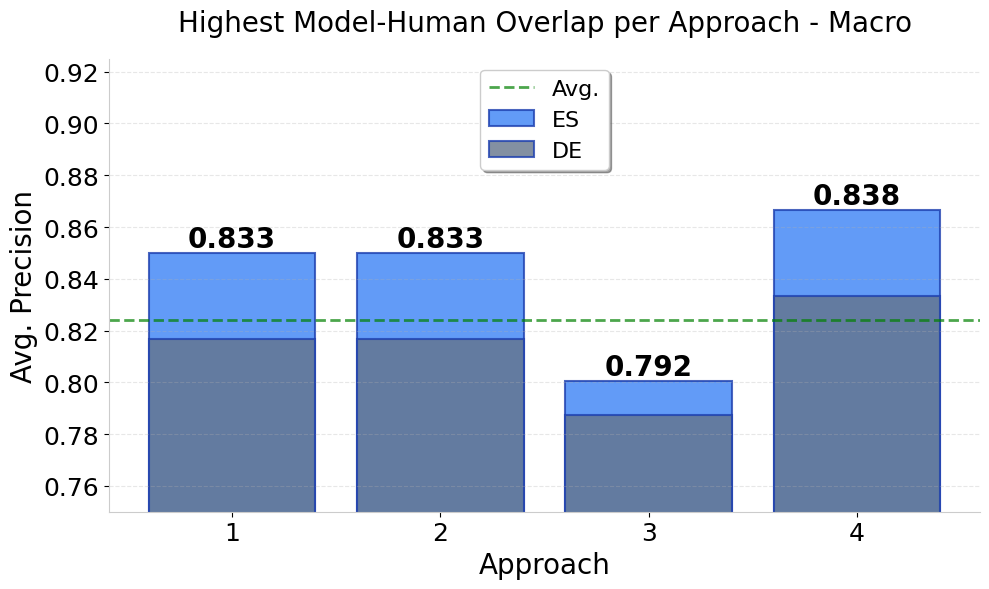


Data Summary for average DE:
----------------------------------------
Score 1: 0.8167
Score 2: 0.8167
Score 3: 0.7872
Score 4: 0.8333

Data Summary for average ES:
----------------------------------------
Score 1: 0.85
Score 2: 0.85
Score 3: 0.8006
Score 4: 0.8667

Data Summary for average DE-ES:
----------------------------------------
Score 1: 0.83335
Score 2: 0.83335
Score 3: 0.7924
Score 4: 0.8375

Peak Performance: 0.8375 at score 4
Lowest Performance: 0.7924 at score 3
Range: 0.7924% - 0.8375 (0.04510000000000003 score spread)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data_dict_DE = top_scores_per_approach_DE
data_dict_ES = top_scores_per_approach_ES
data_dict_DE_ES = top_scores_per_approach_DE_ES

# Extract x and y values
x_values_DE = list(data_dict_DE.keys())
y_values_DE = list(data_dict_DE.values())
x_values_ES = list(data_dict_ES.keys())
y_values_ES = list(data_dict_ES.values())
x_values_DE_ES = list(data_dict_DE_ES.keys())
y_values_DE_ES = list(data_dict_DE_ES.values())

average_overlap = np.mean(y_values_DE_ES)

# Create the bar chart
plt.figure(figsize=(10, 6))
bars_ES = plt.bar(x_values_ES, y_values_ES, color='#3b82f6', alpha=0.8, edgecolor='#1e40af', linewidth=1.5)
bars_DE = plt.bar(x_values_DE, y_values_DE, color='#64748b', alpha=0.8, edgecolor='#1e40af', linewidth=1.5)
#bars_DE_ES = plt.bar(x_values_DE_ES, y_values_DE_ES, color='#3b82f6', alpha=0.8, edgecolor='#1e40af', linewidth=1.5)

# Customize the chart
plt.title('Highest Model-Human Overlap per Approach - Macro',
          fontsize=20, fontweight='medium', pad=20)
plt.xlabel('Approach', fontsize=20, fontweight='medium')
plt.ylabel('Avg. Precision', fontsize=20, fontweight='medium')
plt.tick_params(axis='both', which='major', labelsize=18)

# Add average line
plt.axhline(y=average_overlap, color='green', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Average ({average_overlap:.3f})')

# Add legend
plt.legend(["Avg.", "ES", "DE"], loc='upper center', frameon=True, fancybox=True, shadow=True, fontsize=16)


# Set y-axis limits for better visualization
plt.ylim(0.75, 0.925)

# Add value labels on top of each bar
for bar, value in zip(bars_ES, y_values_DE_ES):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{value:.3f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Customize appearance
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

# Adjust layout and display
plt.tight_layout()
plt.savefig("threshold_approaches_overlap_DE_ES.jpg")
plt.show()

# Optional: Save the figure
# plt.savefig('trigger_words_overlap_chart.png', dpi=300, bbox_inches='tight')

# Print summary statistics
print("\nData Summary for average DE:")
print("-" * 40)
for score, percentage in data_dict_DE.items():
    print(f"Score {score}: {percentage}")

print("\nData Summary for average ES:")
print("-" * 40)
for score, percentage in data_dict_ES.items():
    print(f"Score {score}: {percentage}")


print("\nData Summary for average DE-ES:")
print("-" * 40)
for score, percentage in data_dict_DE_ES.items():
    print(f"Score {score}: {percentage}")

print(f"\nPeak Performance: {max(y_values_DE_ES)} at score {x_values_DE_ES[y_values_DE_ES.index(max(y_values_DE_ES))]}")
print(f"Lowest Performance: {min(y_values_DE_ES)} at score {x_values_DE_ES[y_values_DE_ES.index(min(y_values_DE_ES))]}")
print(f"Range: {min(y_values_DE_ES)}% - {max(y_values_DE_ES)} ({max(y_values_DE_ES) - min(y_values_DE_ES)} score spread)")

## Comparison of all annotators vs. where minimum 2 agree

In [ ]:
print(relative_attribution_DE_threshold)

[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


Min 2 agree DE: [0.6667, 0.6667, 0.6667, 0.6897, 0.6792, 0.6466, 0.6266, 0.629, 0.6154, 0.5906]
Min 2 agree ES: [0.7759, 0.7797, 0.7794, 0.6932, 0.6857, 0.685, 0.6516, 0.6404, 0.6473, 0.6113]


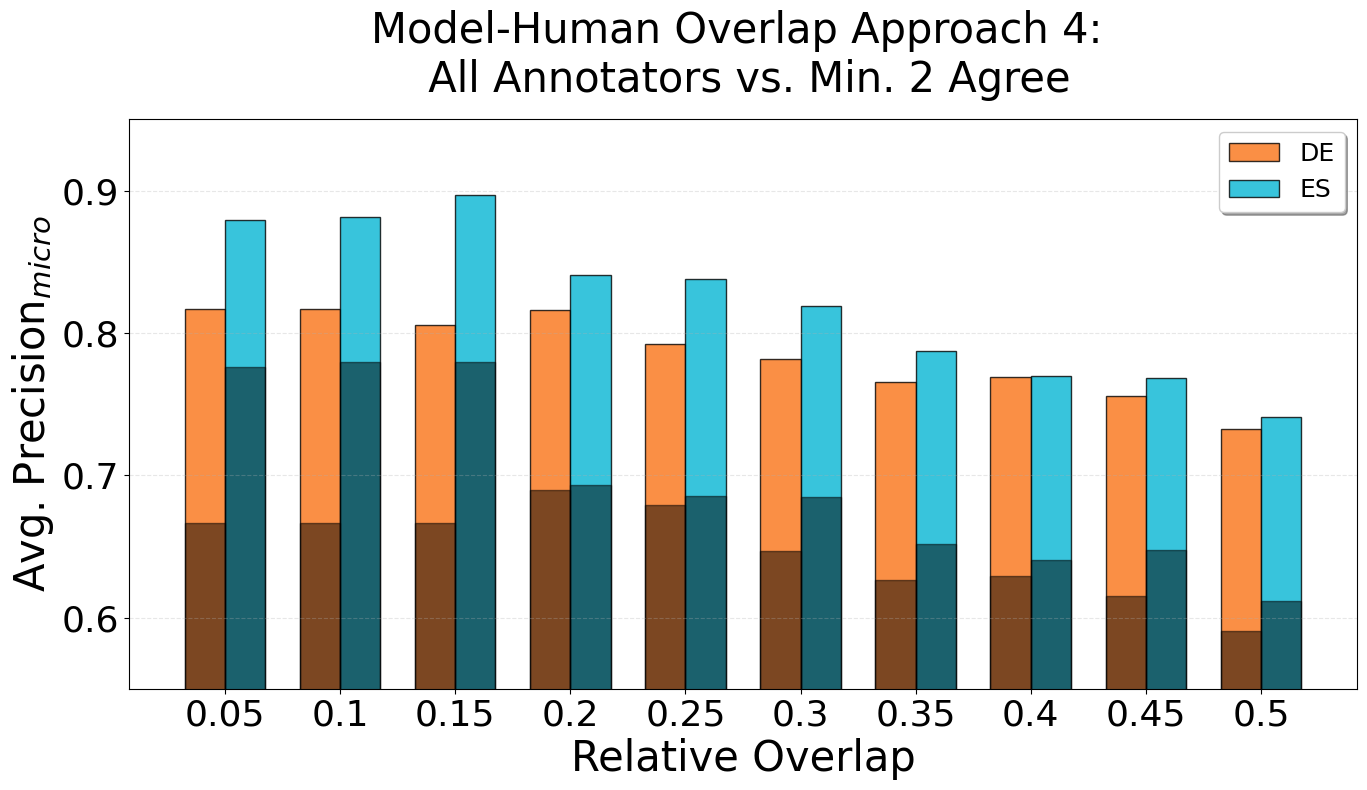

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# APPROACH 4
thresholds = relative_attribution_DE_threshold
min2_agree_avg = min2_relative_attribution_precision_avg
all_avg = relative_attribution_precision_avg
min2_agree_DE = min2_relative_attribution_DE_precision
print(f"Min 2 agree DE: {min2_relative_attribution_DE_precision}")
print(f"Min 2 agree ES: {min2_relative_attribution_ES_precision}")
min2_agree_ES = min2_relative_attribution_ES_precision
all_DE = relative_attribution_DE_precision
all_ES = relative_attribution_ES_precision

x = np.arange(len(thresholds))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))

# Define colours
colors = ['#e11d48', '#f97316', '#eab308', '#22c55e', '#06b6d4',
          '#3b82f6', '#8b5cf6', '#ec4899', '#64748b', '#a855f7']

# Create bars
bars = ax.bar(x- width/2, all_DE, width, color='#f97316', alpha=0.8, edgecolor='black') # DE all (orange)
bars = ax.bar(x+ width/2, all_ES, width, color='#06b6d4', alpha=0.8, edgecolor='black') # ES all (blue)
bars = ax.bar(x- width/2, min2_agree_DE, width,  alpha=0.5, color="black", edgecolor='black') # DE min2 agree (black shaded)
bars = ax.bar(x+ width/2, min2_agree_ES, width,  alpha=0.5, color="black", edgecolor='black') # ES min2 agree (black shaded)


# Set y-axis limits for better visualization
ax.set_ylim(0.55, 0.95)

ax.set_title('Model-Human Overlap Approach 4: \n All Annotators vs. Min. 2 Agree',
             fontsize=30, fontweight='medium', pad=20)
ax.set_xlabel('Relative Overlap', fontsize=30, fontweight='medium')
ax.set_ylabel('Avg. Precision$_{micro}$', fontsize=30, fontweight='medium')
# Add legend
plt.legend(["DE", "ES"], loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=18)

plt.tick_params(axis='both', which='major', labelsize=26)

# Set x-axis with larger font
ax.set_xticks(x)
ax.set_xticklabels(thresholds, fontsize=26)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adjust layout and display
plt.tight_layout()
plt.savefig("approach4_DE_ES_all_annotators_vs_min_2agree.jpg")
plt.show()